<a href="https://colab.research.google.com/github/varun0852/for-study/blob/master/Accuracy_improving_technique.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

In [ ]:
# from google.colab import files
# uploaded = files.upload()


# **THIS IS STATS MODELS APORACH**
## we use stats models if we want statical terms

In [ ]:
df = pd.read_csv("Boston.csv")

In [ ]:
df.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
df1 = df.drop("Unnamed: 0" , axis = 1)

In [ ]:
df1.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


In [ ]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  black    506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


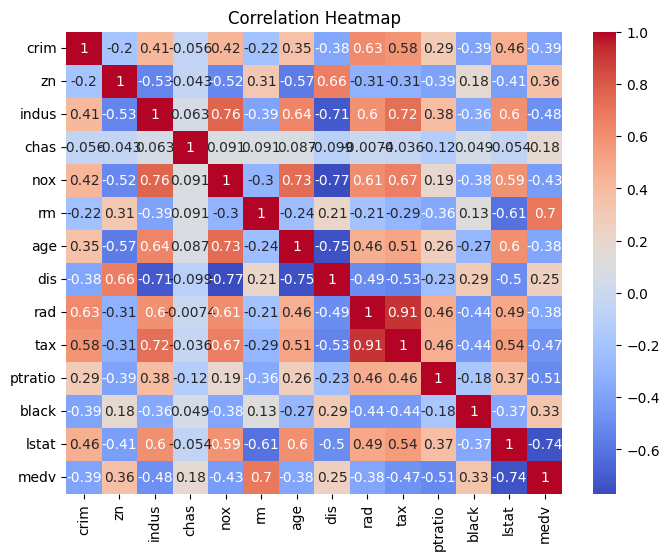

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(df1.corr(),annot=True,cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
x = df1.drop("medv" , axis = 1) # INPUT
y = df1["medv"] # OUTPUT

In [ ]:
x = sm.add_constant(x)

In [ ]:
model = sm.OLS(y,x).fit() # after traingng the data we have solved equation inside mpdel
print(model.summary())
# We can drop insignificent column from the data to check if the model performs well or not
# HOW CAN WE DECIDE INSIGNIFICENT COLUMN ?
# we can check if p>[t] value is greater than 0.05 if it is those columns are insignificant

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.734
Method:                 Least Squares   F-statistic:                     108.1
Date:                Fri, 07 Nov 2025   Prob (F-statistic):          6.72e-135
Time:                        09:41:41   Log-Likelihood:                -1498.8
No. Observations:                 506   AIC:                             3026.
Df Residuals:                     492   BIC:                             3085.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.4595      5.103      7.144      0.0

In [ ]:
y_pred = model.predict(x)

In [ ]:
MSE = mean_squared_error(y,y_pred)
MAE = mean_absolute_error(y,y_pred)
MAPE = np.mean(np.abs((y-y_pred)/y))*100
R2 = r2_score(y,y_pred)

In [ ]:
print(f"MSE: {MSE:.3f}")
print(f"MAE: {MAE:.3f}")
print(f"MAPE: {MAPE:.3f}%") # this is trying to explain the percentage of error we have in our data
print(f"R2: {R2:.3f}") # this is trying to explain correct data that we have

MSE: 21.895
MAE: 3.271
MAPE: 16.417%
R2: 0.741


In [ ]:
residuals = y - y_pred

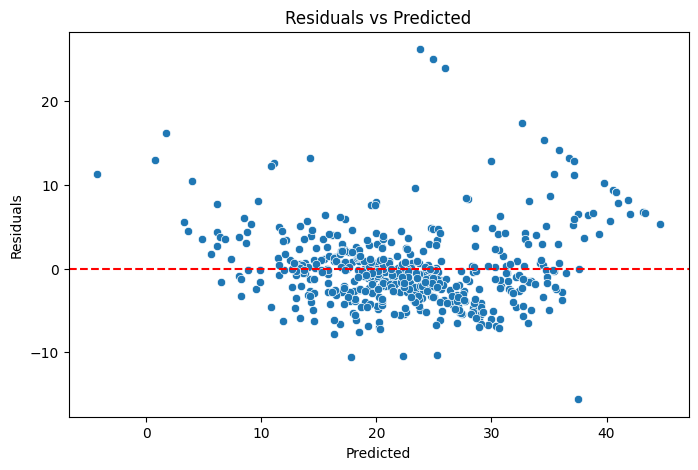

In [ ]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_pred,y=residuals)
plt.axhline(y=0,color="r",linestyle="--")
plt.xlabel("Predicted")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted")
plt.show()

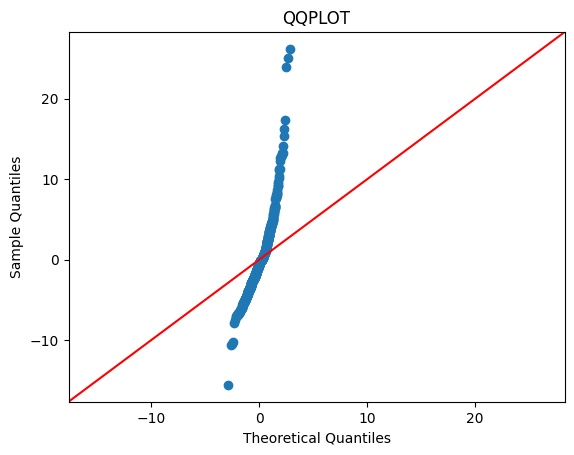

In [ ]:
sm.qqplot(residuals,line = "45")
plt.title("QQPLOT")
plt.show()

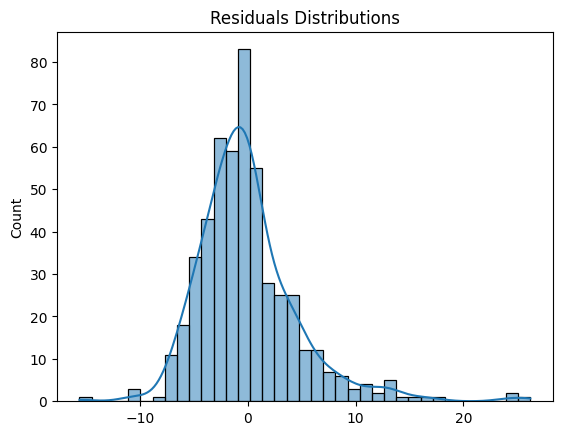

In [ ]:
sns.histplot(residuals,kde=True)
plt.title("Residuals Distributions")
plt.show()

#** VIF**
## Purpose of VIF is to check multicolinearity
#### Range of multicolinarity


*  0 to  5 = no multicolinearity
*  5 to 10 = chances of multicolinearity no need to drop that columns
*  above 10 = there is definetily multicolinearity we must to drop that column







In [ ]:
# Purpose of vif is to check multicolinearity
'''

'''
vif_data = pd.DataFrame()
vif_data["Features"]= x.columns
vif_data["VIF"] = [variance_inflation_factor(x.values,i) for i in range(x.shape[1])]
print("\nVariance Inflation Factor:")
print(vif_data)


Variance Inflation Factor:
   Features         VIF
0     const  585.265238
1      crim    1.792192
2        zn    2.298758
3     indus    3.991596
4      chas    1.073995
5       nox    4.393720
6        rm    1.933744
7       age    3.100826
8       dis    3.955945
9       rad    7.484496
10      tax    9.008554
11  ptratio    1.799084
12    black    1.348521
13    lstat    2.941491


## **TRYING TO CHECK SCORES AFTER DROPING INSIGNIFICANT COLUMN**

In [ ]:
x1 = df1.iloc[:,[0,1,3,4,5,7,8,9,10,11,12]] # INPUT
y1 = df1["medv"] # OUTPUT

In [ ]:
x1

,crim,zn,chas,nox,rm,dis,rad,tax,ptratio,black,lstat
0,0.00632,18.0,0,0.538,6.575,4.0900,1,296,15.3,396.90,4.98
1,0.02731,0.0,0,0.469,6.421,4.9671,2,242,17.8,396.90,9.14
2,0.02729,0.0,0,0.469,7.185,4.9671,2,242,17.8,392.83,4.03
3,0.03237,0.0,0,0.458,6.998,6.0622,3,222,18.7,394.63,2.94
4,0.06905,0.0,0,0.458,7.147,6.0622,3,222,18.7,396.90,5.33
...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,0,0.573,6.593,2.4786,1,273,21.0,391.99,9.67
502,0.04527,0.0,0,0.573,6.120,2.2875,1,273,21.0,396.90,9.08
503,0.06076,0.0,0,0.573,6.976,2.1675,1,273,21.0,396.90,5.64
504,0.10959,0.0,0,0.573,6.794,2.3889,1,273,21.0,393.45,6.48


In [ ]:
x1 = sm.add_constant(x1)

In [ ]:
model = sm.OLS(y1,x1).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                   medv   R-squared:                       0.741
Model:                            OLS   Adj. R-squared:                  0.735
Method:                 Least Squares   F-statistic:                     128.2
Date:                Fri, 07 Nov 2025   Prob (F-statistic):          5.54e-137
Time:                        09:41:43   Log-Likelihood:                -1498.9
No. Observations:                 506   AIC:                             3022.
Df Residuals:                     494   BIC:                             3072.
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         36.3411      5.067      7.171      0.0

# **THIS IS SCIKIT LEARN APPORACH**
## When the goal is r2score , Accuracy , etc

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import linear_model # PARAMETRIC MODEL
from sklearn.tree import DecisionTreeRegressor # NON PARAMETRIC MODEL
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import Normalizer , StandardScaler


In [ ]:
sc = pd.read_csv("Boston.csv")

In [ ]:
sc.head()

,Unnamed: 0,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,1,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,2,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,3,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,4,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,5,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [ ]:
del sc["Unnamed: 0"] # DELETING UNNECESSARY COLUMN

In [ ]:
sc

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,black,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0


In [ ]:
x2 = sc.drop("medv" , axis = 1) # INPUT
y2 = sc["medv"] # OUTPUT

In [ ]:
# SPILLITINGF THE DATA
x_train , x_test , y_train , y_test = train_test_split(x2 , y2 , test_size = 0.2 , random_state = 1142)
# test_size = spliting the data into 80 20 ratio cause we add 0.2 in the above code 80 from training and 20 for testing
# random state is freezing the sample so the accuracy doesn't change

In [ ]:
print(x_train.head())
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

        crim    zn  indus  chas    nox     rm   age     dis  rad  tax  \
465  3.16360   0.0  18.10     0  0.655  5.759  48.2  3.0665   24  666   
29   1.00245   0.0   8.14     0  0.538  6.674  87.3  4.2390    4  307   
198  0.03768  80.0   1.52     0  0.404  7.274  38.3  7.3090    2  329   
174  0.08447   0.0   4.05     0  0.510  5.859  68.7  2.7019    5  296   
248  0.16439  22.0   5.86     0  0.431  6.433  49.1  7.8265    7  330   

     ptratio   black  lstat  
465     20.2  334.40  14.13  
29      21.0  380.23  11.98  
198     12.6  392.20   6.62  
174     16.6  393.23   9.64  
248     19.1  374.71   9.52  
(404,)
(102, 13)
(102,)


In [ ]:
# regr = linear_model.LinearRegression()
regr = DecisionTreeRegressor()

In [ ]:
regr.fit(x_train , y_train)

DecisionTreeRegressor()

In [ ]:
# PRINTING COEFFICIENT
print("Coefficient" , regr.coef_)
print("Intercept" , regr.intercept_)

NameError: name 'regr' is not defined

In [ ]:
# TESTING
y_pred2 = regr.predict(x_test)

In [ ]:
y_pred

array([33.3, 30.1, 25. , 18.4, 19.4, 23.8, 27.5, 21. , 20.1, 12.7, 24.8,
       16.2, 23.8, 20.3, 50. , 24.8, 22.6, 20. , 34.9, 45.4, 31. , 15. ,
       21.7, 17.4, 10.8, 13.1, 23.9, 18.1, 14.9, 19.4, 19.4, 20. , 41.7,
       24.6, 17.8, 33. , 50. ,  8.5, 13.1, 19.9, 18.9, 22. , 13.1, 24.7,
       24.3, 30.1, 20. , 17.8, 14.9, 14.9, 19.4, 20.1, 22.3, 25. , 17.1,
       22.5, 33.1, 34.9,  7.2, 20.6, 10.2, 16.3, 17.4, 35.4, 20.6, 23.9,
       16.2, 31.6, 18.4, 17.4, 10.2, 19.9, 10.2, 16.6, 33.1,  9.6, 25.3,
       50. , 12.8, 22. , 50. , 43.1, 15.6, 14.6, 17.8, 20.5, 23.8, 22.7,
       11.5, 17.5, 32. , 24.7, 23.9, 24.7, 15. , 16.8, 29.6, 48.8,  5.6,
       27.9, 17.8, 13.4])

In [ ]:
# EVALUATION FOR TEST DATA
y_pred2 = regr.predict(x_test)
print(f"R2 Score: {r2_score(y_test , y_pred2):.3f}") # Coefficient of Determination
print(f"Mean Squared Error: {mean_squared_error(y_test , y_pred2):.3f}")

R2 Score: 0.794
Mean Squared Error: 16.589


In [ ]:
# TESTING ACCURACY
y_pred2_tr = regr.predict(x_train)

In [ ]:
# EVALUATION FOR TRAIN DATA
y_pred = regr.predict(x_test)
print(f"R2 Score: {r2_score(y_train , y_pred2_tr):.3f}") # Coefficient of Determination
print(f"Mean Squared Error: {mean_squared_error(y_train , y_pred2_tr):.3f}")

R2 Score: 1.000
Mean Squared Error: 0.000


In [ ]:
# NORMALIZATION BOTH INPUT AND OUTPUT DATA
sc_n = Normalizer().fit_transform(sc)
sc_n = pd.DataFrame(sc)
print(sc_n)

        crim    zn  indus  chas    nox     rm   age     dis  rad  tax  \
0    0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296   
1    0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242   
2    0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242   
3    0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222   
4    0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222   
..       ...   ...    ...   ...    ...    ...   ...     ...  ...  ...   
501  0.06263   0.0  11.93     0  0.573  6.593  69.1  2.4786    1  273   
502  0.04527   0.0  11.93     0  0.573  6.120  76.7  2.2875    1  273   
503  0.06076   0.0  11.93     0  0.573  6.976  91.0  2.1675    1  273   
504  0.10959   0.0  11.93     0  0.573  6.794  89.3  2.3889    1  273   
505  0.04741   0.0  11.93     0  0.573  6.030  80.8  2.5050    1  273   

     ptratio   black  lstat  medv  
0       15.3  396.90   4.98  24.0  
1       17.8  396.90   9.14  21.6  
2       17.8  3